#🔹 Libraries Used

In [1]:
import numpy as np # Numerical operations
import matplotlib.pyplot as plt  # Visualization
from collections import deque # Efficient queue structure for BFS algorithm
import random  # Random operations (used in Genetic Algorithm)

#🔹 GridWorld Class

The GridWorld class represents a 2D grid environment where a depot delivers packages to multiple delivery points.

In [2]:
class GridWorld:
    def __init__(self, depot, points, grid_size=50):

        self.depot = depot
        self.points = points
        self.grid_size = grid_size
        self.distances = []

    def bfs_distance(self, start, end):
        """Calculate shortest path distance using BFS (Manhattan distance for grid)"""
        # For a grid without obstacles, Manhattan distance works
        # But we'll implement BFS for demonstration
        if start == end:
            return 0

        # BFS queue: (position, distance)
        queue = deque([(start, 0)])
        visited = set([start])  # Track visited nodes to avoid repetition

        # Possible moves: up, down, left, right
        moves = [(0, 1), (0, -1), (1, 0), (-1, 0)]

        while queue:
            (x, y), dist = queue.popleft()

            # Explore all possible moves
            for dx, dy in moves:
                nx, ny = x + dx, y + dy

                # Check bounds
                if 0 <= nx <= self.grid_size and 0 <= ny <= self.grid_size:
                    if (nx, ny) == end:
                        return dist + 1

                    if (nx, ny) not in visited:
                        visited.add((nx, ny))
                        queue.append(((nx, ny), dist + 1))

        return float('inf')  # No path found

    def calculate_all_distances(self):
        """Calculate distances from depot to each delivery point"""
        self.distances = []
        for i, point in enumerate(self.points):
            dist = self.bfs_distance(self.depot, point)
            self.distances.append(dist)
            print(f"Distance from Depot to P{i+1}: {dist}")
        return self.distances


#🔹 DeliveryOptimizer Class

The DeliveryOptimizer class uses a Genetic Algorithm (GA) to solve a load balancing problem between two vehicles.

In [3]:
class DeliveryOptimizer:
    def __init__(self, distances, population_size=50, generations=100, mutation_rate=0.1):

      #  distances: list of 6 distances from depot to each point

        self.distances = distances

         # GA parameters
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate
          # Storage
        self.population = []
        self.best_solution = None
        self.best_fitness = float('inf')

    def create_chromosome(self):
        #Create a random binary chromosome of size 6 (0=Vehicle1, 1=Vehicle2)
        return [random.randint(0, 1) for _ in range(6)]

    def initialize_population(self):
           # Generate initial random population
        self.population = [self.create_chromosome() for _ in range(self.population_size)]

    def calculate_fitness(self, chromosome):
        """
        Calculate fitness (lower is better)
        Fitness = |sum_distances_vehicle1 - sum_distances_vehicle2|
        """
        distance_v1 = 0
        distance_v2 = 0

        for i, gene in enumerate(chromosome):
            if gene == 0:  # Vehicle 1
                distance_v1 += self.distances[i]
            else:  # Vehicle 2
                distance_v2 += self.distances[i]

        fitness = abs(distance_v1 - distance_v2)
        return fitness, distance_v1, distance_v2

    def selection(self, num_parents=2):
        #Tournament selection
        # Randomly select individuals for tournament
        tournament = random.sample(self.population, num_parents)

        # Find the best (lowest fitness) individual
        best = min(tournament, key=lambda x: self.calculate_fitness(x)[0])
        return best

    def crossover(self, parent1, parent2):
        #Single-point crossover
        point = random.randint(1, 5)  # Crossover point (1 to 5)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2

    def mutate(self, chromosome):
        # Randomly flip bits based on mutation rate
        for i in range(len(chromosome)):
            if random.random() < self.mutation_rate:
                chromosome[i] = 1 - chromosome[i]  # Flip 0 to 1 or 1 to 0
        return chromosome

    def evolve(self):
        #Run the genetic algorithm
          # Initialize population
        self.initialize_population()

        best_overall = None
        best_fitness_overall = float('inf')
        best_distances = None
        best_fitness_history=[]
        print("\n" + "="*50)
        print("Running Genetic Algorithm...")
        print("="*50)

        # Main GA loop
        for generation in range(self.generations):
            # Evaluate fitness for all chromosomes
            fitness_scores = []
            for chromosome in self.population:
                fitness, v1, v2 = self.calculate_fitness(chromosome)
                fitness_scores.append((fitness, chromosome, v1, v2))

            # Sort by best fitness
            fitness_scores.sort(key=lambda x: x[0])

            # Track best solution
            if fitness_scores[0][0] < best_fitness_overall:
                best_fitness_overall = fitness_scores[0][0]
                best_overall = fitness_scores[0][1].copy()
                best_distances = (fitness_scores[0][2], fitness_scores[0][3])

            # save the best solution for every state
            best_fitness_history.append(best_fitness_overall)

            # Terminate if no improvment for 5 conscutive generations
            if len(best_fitness_history)>4 and len(set(best_fitness_history[-5:]))==1:
              print(f"\n[Termination] convergance reached at gene {generation}.")
              break
            # if we have the best solution break
            if best_fitness_overall==0:
                print(f"\n Best solution reached at gene {generation}.")
                break

            # Print progress every 20 generations
            if generation % 20 == 0:
                print(f"Generation {generation}: Best Fitness = {fitness_scores[0][0]} "
                      f"(V1={fitness_scores[0][2]}, V2={fitness_scores[0][3]})")

            # Create new population
            new_population = []

            # Elitism: keep the best 2 solutions
            new_population.append(fitness_scores[0][1])
            new_population.append(fitness_scores[1][1])

            # Create offspring
            while len(new_population) < self.population_size:
                # Select parents
                parent1 = self.selection()
                parent2 = self.selection()

                # Crossover
                child1, child2 = self.crossover(parent1, parent2)

                # Mutate
                child1 = self.mutate(child1)
                child2 = self.mutate(child2)

                new_population.append(child1)
                if len(new_population) < self.population_size:
                    new_population.append(child2)
             # Update population
            self.population = new_population

          # Store final best
        self.best_solution = best_overall
        self.best_fitness = best_fitness_overall
        self.best_distances = best_distances

        return best_overall, best_fitness_overall, best_distances


#🔹 Visualization

In [4]:
def visualize_solution(depot, points, solution, distances, best_distances):

    # Create figure with 2 plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # LEFT PLOT -> DELIVERY MAP
    ax1 = axes[0]

    # Plot depot
    ax1.scatter( *depot, c='black', s=300, marker='s', label='Depot')

    v1, v2 = [], []

    # Split points based on chromosome
    for i, (p, g) in enumerate(zip(points, solution)):

        if g == 0:
            v1.append((i, p))
        else:
            v2.append((i, p))

    if v1:

        v1_x = [p[1][0] for p in v1]
        v1_y = [p[1][1] for p in v1]

        ax1.scatter(v1_x,v1_y,c='green',s=150,marker='o',label='Vehicle 1')

        for i, p in v1:

            # Dashed line
            ax1.plot(
                [depot[0], p[0]],
                [depot[1], p[1]],
                'g--'
            )

            # Point label
            ax1.text(p[0],p[1],f"P{i+1}\n{distances[i]}",fontsize=8)

    # ---------------- Vehicle 2 ----------------
    if v2:

        v2_x = [p[1][0] for p in v2]
        v2_y = [p[1][1] for p in v2]

        ax1.scatter(v2_x,v2_y,c='orange',s=150,marker='o',label='Vehicle 2' )

        for i, p in v2:

            # Solid line
            ax1.plot([depot[0], p[0]],[depot[1], p[1]],'orange' )

            # Point label
            ax1.text(p[0],p[1],f"P{i+1}\n{distances[i]}",fontsize=8 )

    # INFORMATION BOX
    info_text = (
        f"Vehicle 1 Total Distance = {best_distances[0]}\n"
        f"Vehicle 2 Total Distance = {best_distances[1]}\n"
        f"Difference = {abs(best_distances[0] - best_distances[1])}"
    )

    # Add text box inside first chart
    ax1.text(
        0.02,                 # X position
        0.98,                 # Y position
        info_text, transform=ax1.transAxes,fontsize=10,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    ax1.set_title("Delivery Allocation Map")
    ax1.legend()
    ax1.grid(True)
    ax1.axis("equal")

    # RIGHT PLOT -> TOTAL DISTANCE BAR CHART
    ax2 = axes[1]

    vehicle_names = ['Vehicle 1', 'Vehicle 2']

    total_distances = [ best_distances[0], best_distances[1] ]

    bars = ax2.bar(
        vehicle_names,
        total_distances
    )

    # Add value labels above bars
    for bar in bars:
        height = bar.get_height()

        ax2.text(bar.get_x() + bar.get_width() / 2,height + 0.5,f'{height}',
            ha='center',fontsize=12 )

    ax2.set_title("Total Distance per Vehicle")
    ax2.set_ylabel("Distance")

    # Grid
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    # FINAL DISPLAY
    plt.show()

#🔹 User Input Handling with Validation

In [5]:
def get_user_input():
    """Get coordinates from user with boundary validation"""

    print("\n" + "="*50)
    print("DELIVERY ALLOCATION SYSTEM - LOAD BALANCING")
    print("="*50)

    # -------- Helper Function (Clamp Values) --------
    def clamp(value, min_val=0, max_val=50):
        """
        Ensures value stays within [min_val, max_val]
        """
        return max(min_val, min(max_val, value))

    # ------------------ Depot ------------------
    print("\n--- Depot Location ---")

    depot_x = int(input("Enter Depot X coordinate (0-50): "))
    depot_y = int(input("Enter Depot Y coordinate (0-50): "))

    # Apply boundary limits
    depot_x = clamp(depot_x)
    depot_y = clamp(depot_y)

    depot = (depot_x, depot_y)

    # ------------------ Delivery Points ------------------
    points = []
    print("\n--- Delivery Points (P1 to P6) ---")

    for i in range(6):
        print(f"\nPoint P{i+1}:")

        x = int(input(f"  Enter X coordinate (0-50): "))
        y = int(input(f"  Enter Y coordinate (0-50): "))

        # Apply boundary limits
        x = clamp(x)
        y = clamp(y)

        points.append((x, y))

    return depot, points

#🔹 Using Example Data Function

In [6]:
def use_example_data():
    """Use example coordinates if user doesn't want to enter"""
    print("\nUsing example coordinates...")
    depot = (25, 25)
    points = [(10, 10), (40, 10), (10, 40), (40, 40), (25, 5), (25, 45)]
    return depot, points

#🔹 Main Execution Flow


Do you want to:
1. Enter custom coordinates
2. Use example coordinates
Enter choice (1 or 2): 2

Using example coordinates...

CALCULATING SHORTEST PATHS USING BFS...
Distance from Depot to P1: 30
Distance from Depot to P2: 30
Distance from Depot to P3: 30
Distance from Depot to P4: 30
Distance from Depot to P5: 20
Distance from Depot to P6: 20

Running Genetic Algorithm...

 Best solution reached at gene 0.

FINAL RESULTS

Best Chromosome (Vehicle Assignment):
P1  P2  P3  P4  P5  P6
0   1   1   0   0   1

(0 = Vehicle 1, 1 = Vehicle 2)

Assignment Details:
P1: (10, 10) -> Vehicle 1 (Distance: 30)
P2: (40, 10) -> Vehicle 2 (Distance: 30)
P3: (10, 40) -> Vehicle 2 (Distance: 30)
P4: (40, 40) -> Vehicle 1 (Distance: 30)
P5: (25, 5) -> Vehicle 1 (Distance: 20)
P6: (25, 45) -> Vehicle 2 (Distance: 20)

Vehicle 1 Total Distance: 80
Vehicle 2 Total Distance: 80
Balance Difference: 0

🎉 PERFECT BALANCE ACHIEVED! 🎉

Generating visualization...


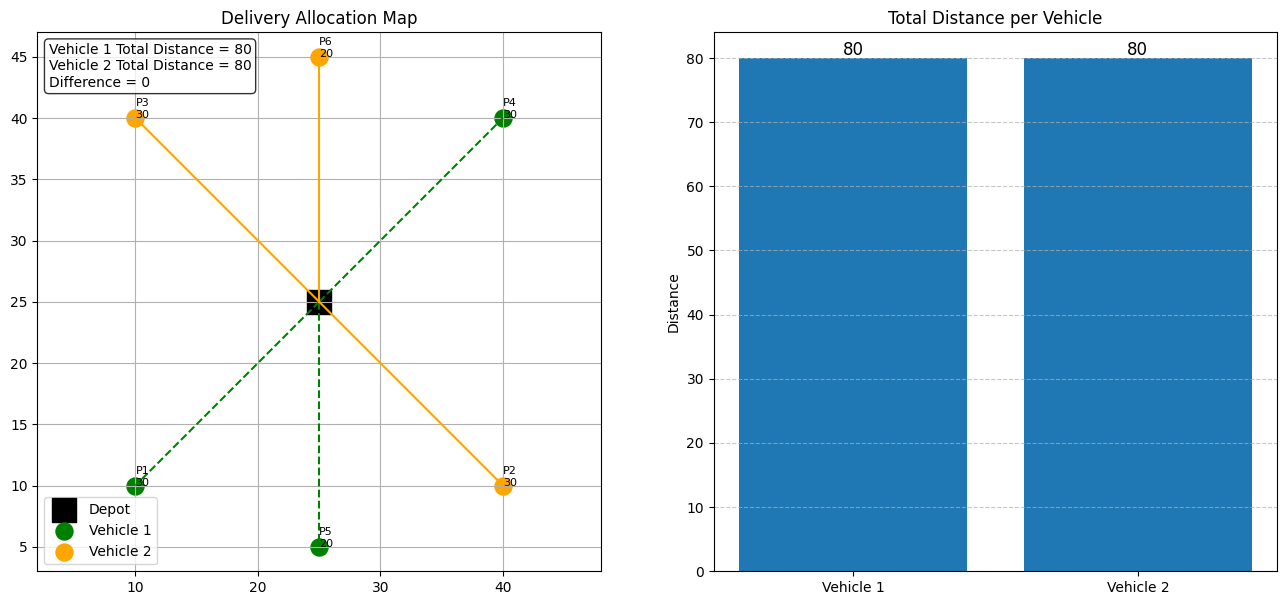

In [7]:
def main():

    # ------------------ INPUT SELECTION ------------------
    print("\nDo you want to:")
    print("1. Enter custom coordinates")
    print("2. Use example coordinates")

    choice = input("Enter choice (1 or 2): ")

    # Load dataset based on user choice
    if choice == '1':
        depot, points = get_user_input()
    else:
        depot, points = use_example_data()

    # ------------------ BFS DISTANCE CALCULATION ------------------
    print("\n" + "="*50)
    print("CALCULATING SHORTEST PATHS USING BFS...")
    print("="*50)

    # Create grid world
    grid = GridWorld(depot, points, grid_size=50)

    # Compute distances from depot to all points
    distances = grid.calculate_all_distances()

    # ------------------ GENETIC ALGORITHM ------------------
    optimizer = DeliveryOptimizer(
        distances,
        population_size=100,
        generations=200,
        mutation_rate=0.1
    )

    # Run optimization
    best_solution, best_fitness, best_distances = optimizer.evolve()

    # ------------------ OUTPUT RESULTS ------------------
    print("\n" + "="*50)
    print("FINAL RESULTS")
    print("="*50)

    # Print chromosome
    print("\nBest Chromosome (Vehicle Assignment):")
    print("P1  P2  P3  P4  P5  P6")
    print(
        f"{best_solution[0]}   {best_solution[1]}   {best_solution[2]}   "
        f"{best_solution[3]}   {best_solution[4]}   {best_solution[5]}"
    )

    print("\n(0 = Vehicle 1, 1 = Vehicle 2)")

    # Print assignment details
    print("\nAssignment Details:")
    for i, (point, assignment, dist) in enumerate(zip(points, best_solution, distances)):
        vehicle = "Vehicle 1" if assignment == 0 else "Vehicle 2"
        print(f"P{i+1}: {point} -> {vehicle} (Distance: {dist})")

    # Print final totals
    print(f"\nVehicle 1 Total Distance: {best_distances[0]}")
    print(f"Vehicle 2 Total Distance: {best_distances[1]}")
    print(f"Balance Difference: {best_fitness}")

    # Check optimality
    if best_fitness == 0:
        print("\n🎉 PERFECT BALANCE ACHIEVED! 🎉")
    else:
        print(f"\nLoad imbalance: {best_fitness} units")

    # ------------------ VISUALIZATION ------------------
    print("\nGenerating visualization...")
    visualize_solution(depot, points, best_solution, distances, best_distances)


# Run program only if file is executed directly
if __name__ == "__main__":
    main()